# 🍌 BananaNet — Klasifikasi Tingkat Kematangan Buah Pisang
## Menggunakan Transfer Learning ResNet50 dan VGG16

| Info | Detail |
|------|--------|
| **Kelas** | Overripe · Ripe · Unripe |
| **Arsitektur** | ResNet50, VGG16 (Transfer Learning) |
| **Framework** | TensorFlow / Keras |
| **Dataset** | Lokal — `dataset/train`, `dataset/val`, `dataset/test` |

---

## 1. Install Library

In [1]:
!pip install scikit-image seaborn --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Library

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from skimage.feature import graycomatrix, graycoprops

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow :", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.20.0
GPU tersedia: []


## 3. Konfigurasi Path Dataset dan Parameter

In [3]:
import os

# ══════════════════════════════════════════════════════════
# SESUAIKAN PATH INI DENGAN LOKASI DATASET DI KOMPUTER KAMU
# ══════════════════════════════════════════════════════════
TRAIN_PATH = r"D:\BANANA_NIAN\dataset\train"
VAL_PATH   = r"D:\BANANA_NIAN\dataset\val"
TEST_PATH  = r"D:\BANANA_NIAN\dataset\test"
# ══════════════════════════════════════════════════════════

# ── Hyperparameter ─────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 10
LR          = 0.0001

# ── Auto-detect nama kelas dari folder train ───────────────
CLASSES = sorted([
    d for d in os.listdir(TRAIN_PATH)
    if os.path.isdir(os.path.join(TRAIN_PATH, d))
])
NUM_CLASSES = len(CLASSES)

print("Kelas terdeteksi:", CLASSES)
print("Jumlah kelas    :", NUM_CLASSES)

# ── Verifikasi folder & jumlah gambar ──────────────────────
for split_name, path in [("Train", TRAIN_PATH), ("Val", VAL_PATH), ("Test", TEST_PATH)]:
    if os.path.isdir(path):
        total = sum(
            len([f for f in os.listdir(os.path.join(path, k))
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
            for k in os.listdir(path)
            if os.path.isdir(os.path.join(path, k))
        )
        print(f"  ✓ {split_name:5s} → {path}  ({total} gambar)")
    else:
        print(f"  ✗ {split_name:5s} → {path}  TIDAK DITEMUKAN!")

Kelas terdeteksi: ['Overripe', 'Ripe', 'Unripe']
Jumlah kelas    : 3
  ✓ Train → D:\BANANA_NIAN\dataset\train  (7773 gambar)
  ✓ Val   → D:\BANANA_NIAN\dataset\val  (735 gambar)
  ✓ Test  → D:\BANANA_NIAN\dataset\test  (377 gambar)


## 4. Distribusi Jumlah Data per Kelas

Kelas            Train       Val      Test
------------------------------------------
Overripe          2349       229       113
Ripe              3522       339       154
Unripe            1902       167       110


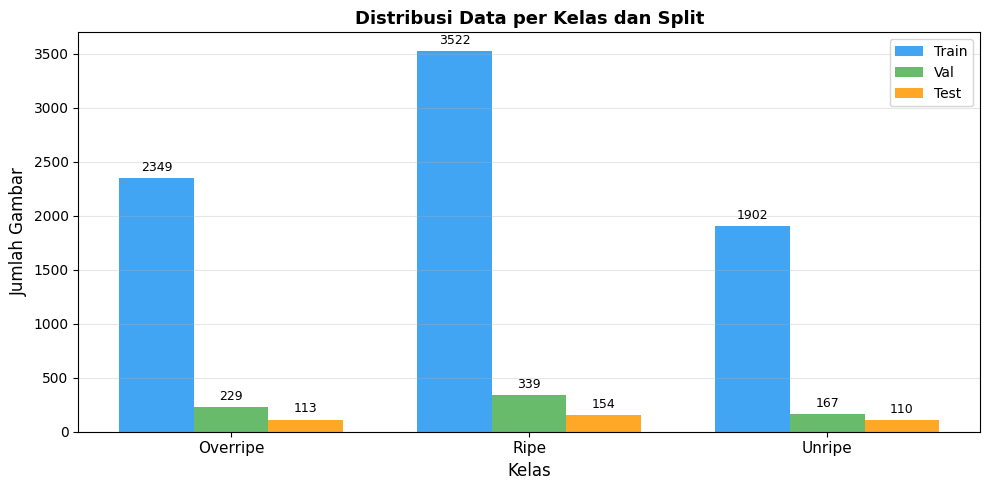

In [4]:
splits = {"Train": TRAIN_PATH, "Val": VAL_PATH, "Test": TEST_PATH}
data_counts = {}

print(f"{'Kelas':<12}", end="")
for split in splits:
    print(f"{split:>10}", end="")
print()
print("-" * 42)

for kelas in CLASSES:
    print(f"{kelas:<12}", end="")
    data_counts[kelas] = {}
    for split, path in splits.items():
        folder = os.path.join(path, kelas)
        n = len([f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]) if os.path.isdir(folder) else 0
        data_counts[kelas][split] = n
        print(f"{n:>10}", end="")
    print()

# Bar chart distribusi
x = np.arange(len(CLASSES))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (split, color) in enumerate(zip(splits.keys(), colors)):
    vals = [data_counts[k][split] for k in CLASSES]
    bars = ax.bar(x + i*width, vals, width, label=split, color=color, alpha=0.85)
    ax.bar_label(bars, padding=3, fontsize=9)

ax.set_xlabel("Kelas", fontsize=12)
ax.set_ylabel("Jumlah Gambar", fontsize=12)
ax.set_title("Distribusi Data per Kelas dan Split", fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(CLASSES, fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Visualisasi Sampel Citra per Kelas

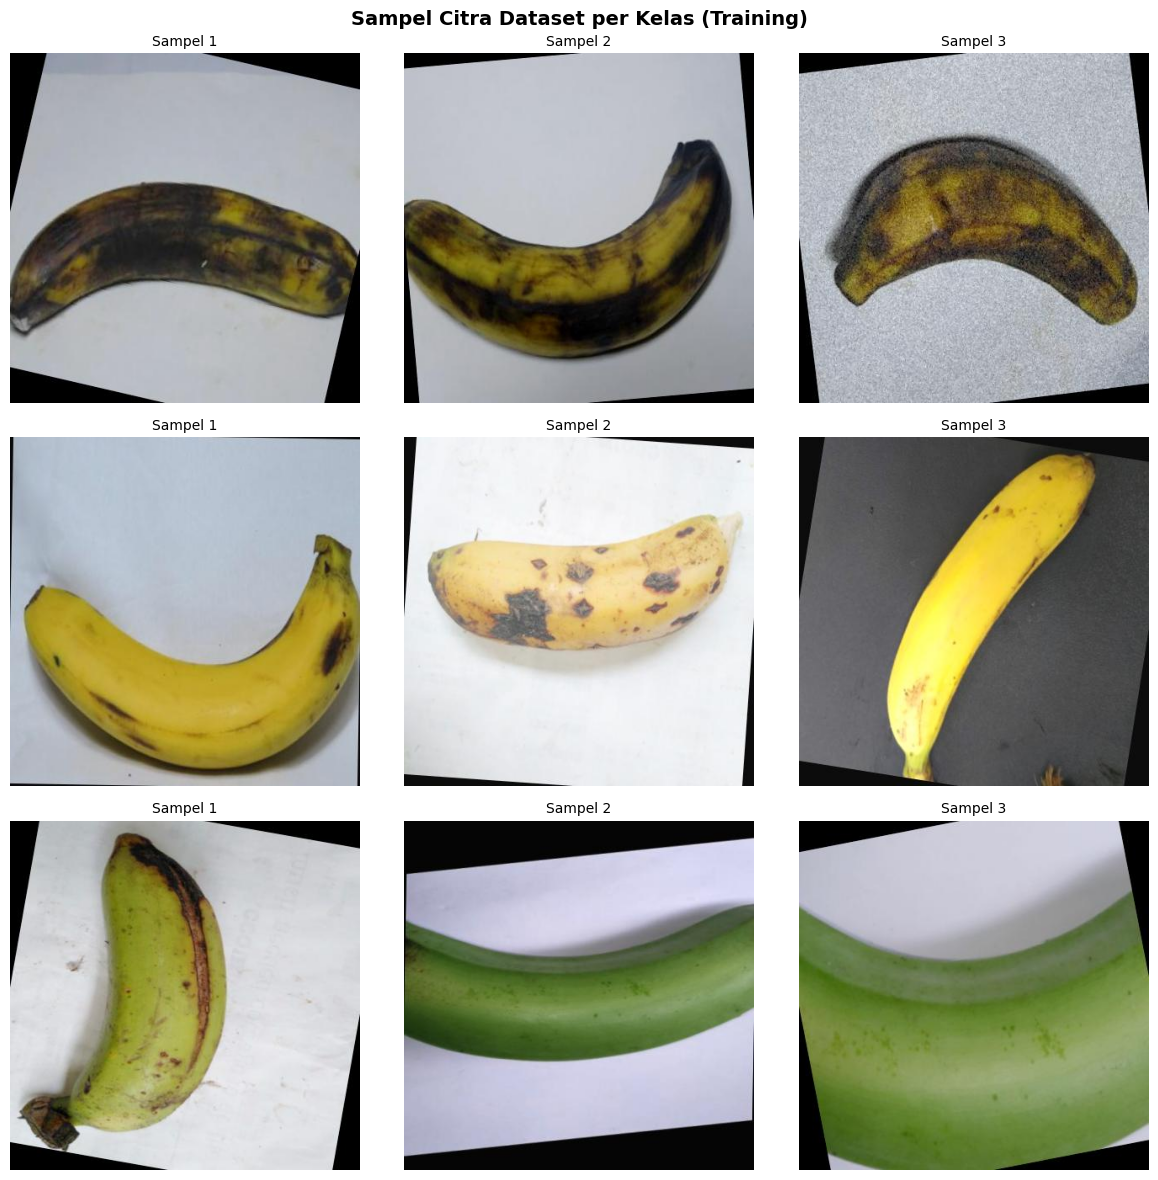

In [5]:
fig, axes = plt.subplots(len(CLASSES), 3, figsize=(12, 4 * len(CLASSES)))

for row, kelas in enumerate(CLASSES):
    folder = os.path.join(TRAIN_PATH, kelas)
    files  = [f for f in os.listdir(folder)
               if f.lower().endswith(('.jpg','.jpeg','.png'))]
    sampel = random.sample(files, min(3, len(files)))

    for col, fname in enumerate(sampel):
        img = cv2.imread(os.path.join(folder, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(kelas, fontsize=13, fontweight='bold', rotation=90, labelpad=10)
        axes[row][col].set_title(f"Sampel {col+1}", fontsize=10)

plt.suptitle("Sampel Citra Dataset per Kelas (Training)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Analisis Warna Citra — RGB vs HSV

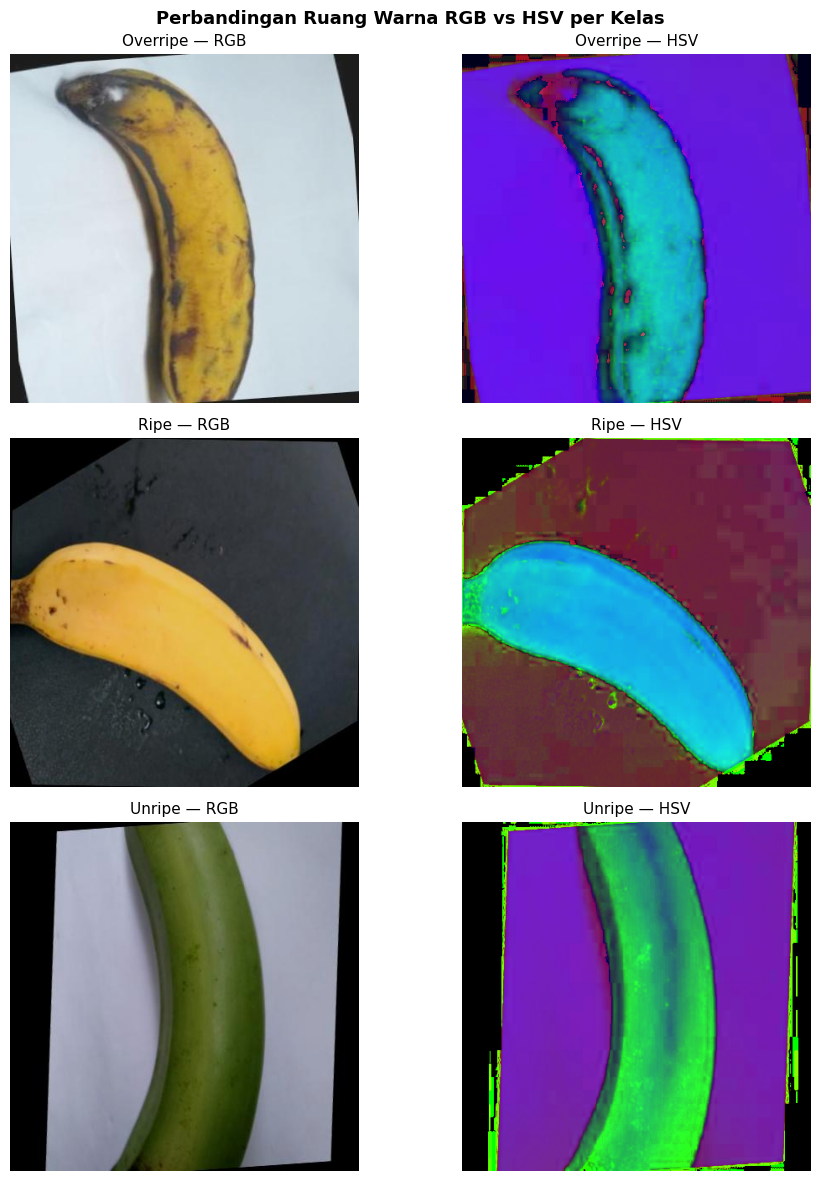

In [ ]:
fig, axes = plt.subplots(len(CLASSES), 2, figsize=(10, 4 * len(CLASSES)))

for row, kelas in enumerate(CLASSES):
    folder = os.path.join(TRAIN_PATH, kelas)
    files  = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    img    = cv2.imread(os.path.join(folder, files[0]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    axes[row][0].imshow(img_rgb)
    axes[row][0].set_title(f"{kelas} — RGB", fontsize=11)
    axes[row][0].axis('off')

    axes[row][1].imshow(img_hsv)
    axes[row][1].set_title(f"{kelas} — HSV", fontsize=11)
    axes[row][1].axis('off')

plt.suptitle("Perbandingan Ruang Warna RGB vs HSV per Kelas", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Histogram Warna RGB per Kelas

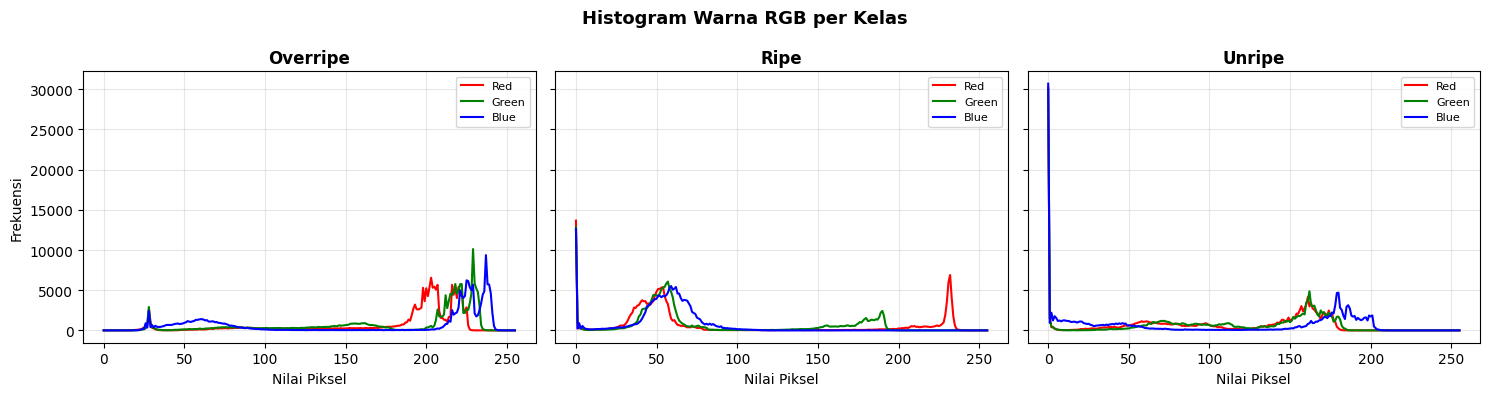

In [7]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(15, 4), sharey=True)
ch_colors = [('r','Red'), ('g','Green'), ('b','Blue')]

for col, kelas in enumerate(CLASSES):
    folder = os.path.join(TRAIN_PATH, kelas)
    files  = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    img    = cv2.imread(os.path.join(folder, files[0]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for i, (color, label) in enumerate(ch_colors):
        hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
        axes[col].plot(hist, color=color, label=label, linewidth=1.5)

    axes[col].set_title(kelas, fontsize=12, fontweight='bold')
    axes[col].set_xlabel("Nilai Piksel")
    if col == 0:
        axes[col].set_ylabel("Frekuensi")
    axes[col].legend(fontsize=8)
    axes[col].grid(alpha=0.3)

plt.suptitle("Histogram Warna RGB per Kelas", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Ekstraksi Fitur Tekstur GLCM per Kelas

In [8]:
print(f"{'Kelas':<12} {'Contrast':>12} {'Energy':>10} {'Homogeneity':>14} {'Correlation':>13}")
print("-" * 63)

glcm_results = {}
for kelas in CLASSES:
    folder = os.path.join(TRAIN_PATH, kelas)
    files  = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    img_gray = cv2.imread(os.path.join(folder, files[0]), cv2.IMREAD_GRAYSCALE)

    glcm = graycomatrix(img_gray, distances=[1], angles=[0],
                        levels=256, symmetric=True, normed=True)
    contrast    = graycoprops(glcm, 'contrast')[0, 0]
    energy      = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    glcm_results[kelas] = [contrast, energy, homogeneity, correlation]

    print(f"{kelas:<12} {contrast:>12.4f} {energy:>10.4f} {homogeneity:>14.4f} {correlation:>13.4f}")

Kelas            Contrast     Energy    Homogeneity   Correlation
---------------------------------------------------------------
Overripe          67.7461     0.1066         0.6776        0.9890
Ripe              20.4303     0.0975         0.6378        0.9970
Unripe            75.3817     0.1791         0.6883        0.9911


## 9. Preprocessing dan Augmentasi Data

| Parameter | Training | Validasi | Testing |
|-----------|----------|----------|---------|
| Rescale | 1/255 | 1/255 | 1/255 |
| Rotation | 20° | ✗ | ✗ |
| Zoom | 20% | ✗ | ✗ |
| Horizontal Flip | ✓ | ✗ | ✗ |
| Brightness | [0.8–1.2] | ✗ | ✗ |
| Shuffle | ✓ | ✗ | ✗ |

In [9]:
# Training — dengan augmentasi
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Validasi & Test — hanya rescale
eval_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=True,
    seed=42
)

val_generator = eval_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False  # PENTING: False agar urutan konsisten saat evaluasi
)

test_generator = eval_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False
)

print(f"Indeks kelas  : {train_generator.class_indices}")
print(f"Train — {train_generator.samples} gambar, {len(train_generator)} steps/epoch")
print(f"Val   — {val_generator.samples} gambar, {len(val_generator)} steps/epoch")
print(f"Test  — {test_generator.samples} gambar, {len(test_generator)} steps/epoch")

Found 7773 images belonging to 3 classes.
Found 735 images belonging to 3 classes.
Found 377 images belonging to 3 classes.
Indeks kelas  : {'Overripe': 0, 'Ripe': 1, 'Unripe': 2}
Train — 7773 gambar, 243 steps/epoch
Val   — 735 gambar, 23 steps/epoch
Test  — 377 gambar, 12 steps/epoch


## 10. Visualisasi Hasil Augmentasi Data

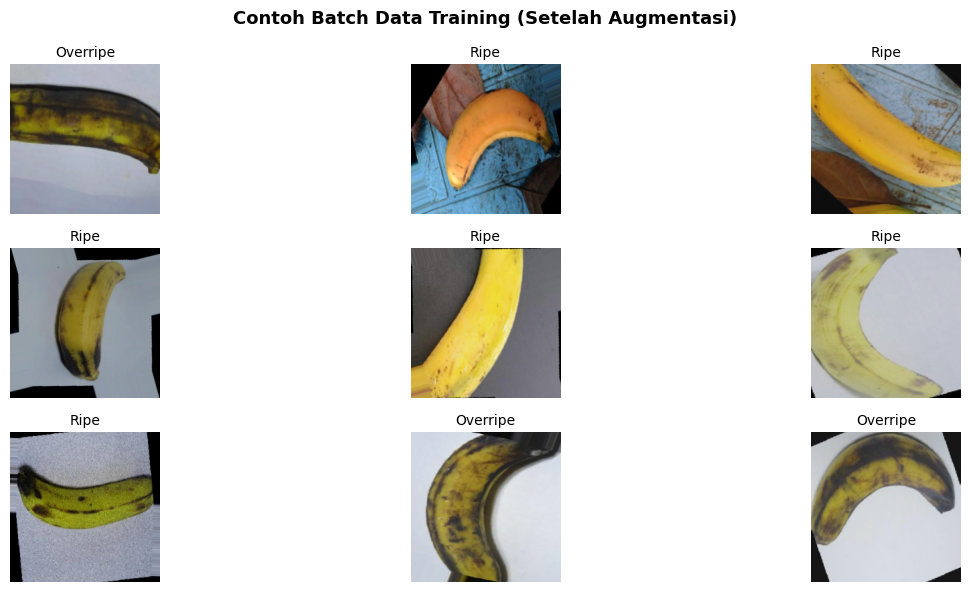

In [10]:
images_batch, labels_batch = next(train_generator)

plt.figure(figsize=(14, 6))
for i in range(min(9, len(images_batch))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch[i])
    idx   = np.argmax(labels_batch[i])
    nama  = CLASSES[idx]
    plt.title(nama, fontsize=10)
    plt.axis('off')

plt.suptitle("Contoh Batch Data Training (Setelah Augmentasi)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Callback — EarlyStopping & ReduceLROnPlateau

In [11]:
# Hanya pakai EarlyStopping (ReduceLROnPlateau tidak kompatibel dengan NumPy 2.0)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]
print("Callbacks siap.")

Callbacks siap.


## 12. Model ResNet50 — Transfer Learning

- **Base**: ResNet50 (ImageNet, `include_top=False`, `trainable=False`)
- **Head**: GlobalAveragePooling2D → Dense(256, ReLU) → Dropout(0.5) → Dense(3, Softmax)

In [12]:
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_resnet.trainable = False

model_resnet = Sequential([
    base_resnet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name='ResNet50_BananaNet')

model_resnet.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

Model: "ResNet50_BananaNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape              ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ ?                         │ 23,587,712 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ global_average_pooling2d        │ ?                         │          0 │
│ (GlobalAveragePooling2D)        │                           │  (unbuilt) │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ dense (Dense)                   │ ?                         │          0 │
│                                 │                           │  (unbuilt) │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ dropout (Dropout)               │ ?                         │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ dense_1 (Dense)                 │ ?                         │          0 │
│                                 │                           │  (unbuilt) │
└─────────────────────────────────┴───────────────────────────┴────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

### 12.1 Training ResNet50

In [13]:
print("=" * 55)
print("  TRAINING RESNET50")
print("=" * 55)

history_resnet = model_resnet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

  TRAINING RESNET50
Epoch 1/10


c:\Users\HYPE AMD\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


243/243 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.4088 - loss: 1.1688 - val_accuracy: 0.4721 - val_loss: 1.0323
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.4647 - loss: 1.0414 - val_accuracy: 0.4871 - val_loss: 1.0192
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 245s 1s/step - accuracy: 0.4827 - loss: 1.0275 - val_accuracy: 0.4898 - val_loss: 1.0090
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.5048 - loss: 1.0042 - val_accuracy: 0.5020 - val_loss: 0.9899
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.5129 - loss: 0.9968 - val_accuracy: 0.4898 - val_loss: 0.9905
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.5236 - loss: 0.9828 - val_accuracy: 0.5061 - val_loss: 0.9692
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.5260 - loss: 0.9754 - val_accuracy: 0.5429 - val_loss: 0.9545
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.5308 - loss: 0.9758 - val_accuracy: 0.515

### 12.2 Evaluasi ResNet50 pada Data Validasi

In [14]:
loss_resnet, acc_resnet = model_resnet.evaluate(val_generator, verbose=0)
print(f"Val Loss     : {loss_resnet:.4f}")
print(f"Val Accuracy : {acc_resnet:.4f}  ({acc_resnet*100:.2f}%)")

Val Loss     : 0.9263
Val Accuracy : 0.5374  (53.74%)


## 13. Model VGG16 — Transfer Learning

- **Base**: VGG16 (ImageNet, `include_top=False`, `trainable=False`)
- **Head**: Flatten → Dense(256, ReLU) → Dropout(0.5) → Dense(3, Softmax)

In [15]:
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_vgg.trainable = False

model_vgg = Sequential([
    base_vgg,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name='VGG16_BananaNet')

model_vgg.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

Model: "VGG16_BananaNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape              ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ ?                         │ 14,714,688 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ flatten (Flatten)               │ ?                         │          0 │
│                                 │                           │  (unbuilt) │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ dense_2 (Dense)                 │ ?                         │          0 │
│                                 │                           │  (unbuilt) │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ dropout_1 (Dropout)             │ ?                         │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ dense_3 (Dense)                 │ ?                         │          0 │
│                                 │                           │  (unbuilt) │
└─────────────────────────────────┴───────────────────────────┴────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### 13.1 Training VGG16

In [16]:
print("=" * 55)
print("  TRAINING VGG16")
print("=" * 55)

history_vgg = model_vgg.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

  TRAINING VGG16
Epoch 1/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 498s 2s/step - accuracy: 0.7333 - loss: 0.6423 - val_accuracy: 0.9701 - val_loss: 0.1304
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 500s 2s/step - accuracy: 0.9425 - loss: 0.1813 - val_accuracy: 0.9714 - val_loss: 0.1029
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 489s 2s/step - accuracy: 0.9490 - loss: 0.1460 - val_accuracy: 0.9728 - val_loss: 0.0971
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 505s 2s/step - accuracy: 0.9579 - loss: 0.1181 - val_accuracy: 0.9864 - val_loss: 0.0678
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/step - accuracy: 0.9663 - loss: 0.0988 - val_accuracy: 0.9850 - val_loss: 0.0570
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 500s 2s/step - accuracy: 0.9701 - loss: 0.0870 - val_accuracy: 0.9850 - val_loss: 0.0503
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 490s 2s/step - accuracy: 0.9692 - loss: 0.0860 - val_accuracy: 0.9864 - val_loss: 0.0411
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 494s 2s/step - accuracy: 0.9764 - loss: 

### 13.2 Evaluasi VGG16 pada Data Validasi

In [17]:
loss_vgg, acc_vgg = model_vgg.evaluate(val_generator, verbose=0)
print(f"Val Loss     : {loss_vgg:.4f}")
print(f"Val Accuracy : {acc_vgg:.4f}  ({acc_vgg*100:.2f}%)")

Val Loss     : 0.0333
Val Accuracy : 0.9905  (99.05%)


## 14. Perbandingan Akurasi ResNet50 vs VGG16

In [18]:
print("╔══════════════════════════════════════╗")
print("║       PERBANDINGAN MODEL             ║")
print("╠══════════════════════════════════════╣")
print(f"║  ResNet50 Val Accuracy : {acc_resnet:.4f} ({acc_resnet*100:.2f}%) ║")
print(f"║  VGG16    Val Accuracy : {acc_vgg:.4f} ({acc_vgg*100:.2f}%) ║")
print("╠══════════════════════════════════════╣")
if acc_resnet >= acc_vgg:
    print(f"║  ✓ ResNet50 lebih unggul +{(acc_resnet-acc_vgg)*100:.2f}%       ║")
else:
    print(f"║  ✓ VGG16 lebih unggul    +{(acc_vgg-acc_resnet)*100:.2f}%       ║")
print("╚══════════════════════════════════════╝")

╔══════════════════════════════════════╗
║       PERBANDINGAN MODEL             ║
╠══════════════════════════════════════╣
║  ResNet50 Val Accuracy : 0.5374 (53.74%) ║
║  VGG16    Val Accuracy : 0.9905 (99.05%) ║
╠══════════════════════════════════════╣
║  ✓ VGG16 lebih unggul    +45.31%       ║
╚══════════════════════════════════════╝


## 15. Grafik Learning Curve

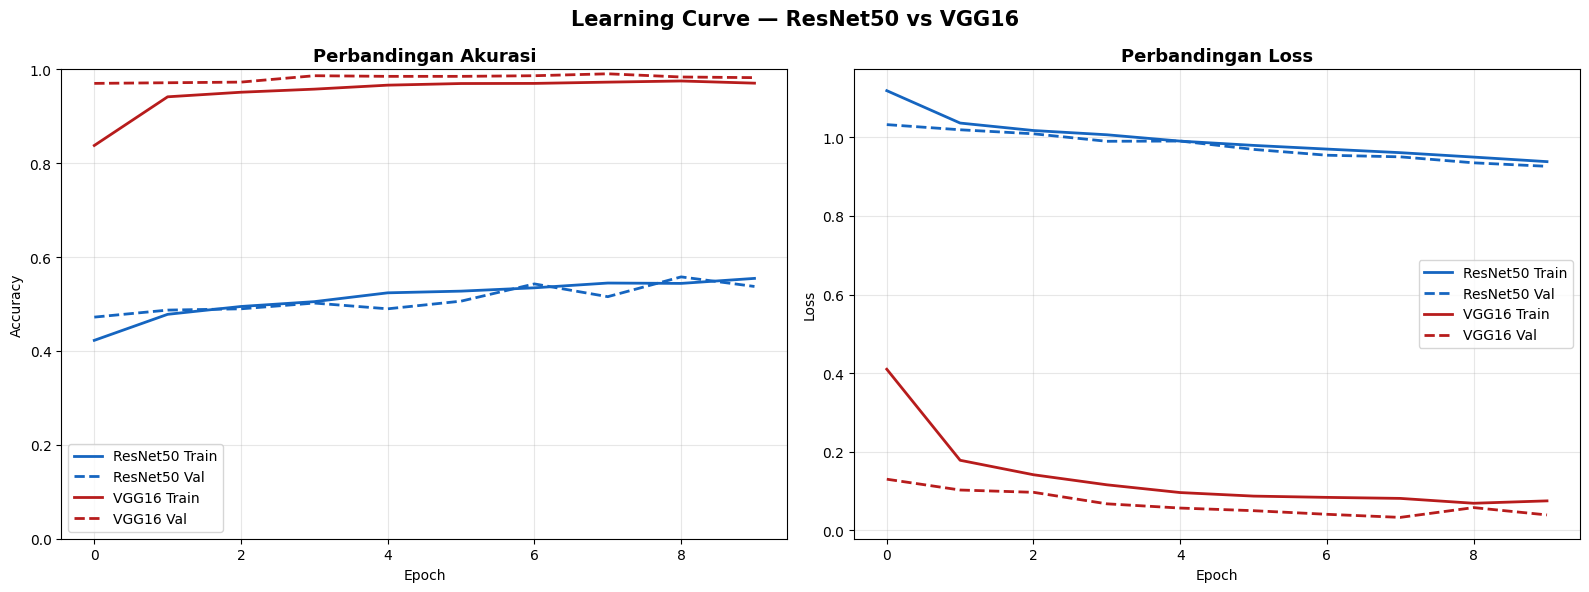

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
axes[0].plot(history_resnet.history['accuracy'],     label='ResNet50 Train', color='#1565C0', linewidth=2)
axes[0].plot(history_resnet.history['val_accuracy'], label='ResNet50 Val',   color='#1565C0', linewidth=2, linestyle='--')
axes[0].plot(history_vgg.history['accuracy'],        label='VGG16 Train',    color='#B71C1C', linewidth=2)
axes[0].plot(history_vgg.history['val_accuracy'],    label='VGG16 Val',      color='#B71C1C', linewidth=2, linestyle='--')
axes[0].set_title('Perbandingan Akurasi', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 1])

# Loss
axes[1].plot(history_resnet.history['loss'],     label='ResNet50 Train', color='#1565C0', linewidth=2)
axes[1].plot(history_resnet.history['val_loss'], label='ResNet50 Val',   color='#1565C0', linewidth=2, linestyle='--')
axes[1].plot(history_vgg.history['loss'],        label='VGG16 Train',    color='#B71C1C', linewidth=2)
axes[1].plot(history_vgg.history['val_loss'],    label='VGG16 Val',      color='#B71C1C', linewidth=2, linestyle='--')
axes[1].set_title('Perbandingan Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Learning Curve — ResNet50 vs VGG16', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Evaluasi pada Data Test

### 16.1 Confusion Matrix & Classification Report — ResNet50

12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step 


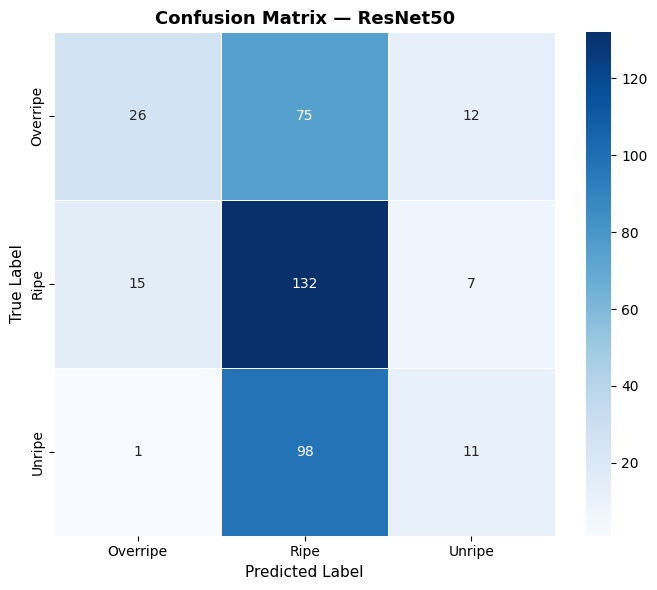

Classification Report — ResNet50
              precision    recall  f1-score   support

    Overripe       0.62      0.23      0.34       113
        Ripe       0.43      0.86      0.58       154
      Unripe       0.37      0.10      0.16       110

    accuracy                           0.45       377
   macro avg       0.47      0.40      0.36       377
weighted avg       0.47      0.45      0.38       377



In [20]:
test_generator.reset()
y_pred_resnet = np.argmax(model_resnet.predict(test_generator, verbose=1), axis=1)
y_true        = test_generator.classes

cm_resnet = confusion_matrix(y_true, y_pred_resnet)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5)
plt.title('Confusion Matrix — ResNet50', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()

print("Classification Report — ResNet50")
print("=" * 55)
print(classification_report(y_true, y_pred_resnet, target_names=CLASSES))

### 16.2 Confusion Matrix & Classification Report — VGG16

12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step


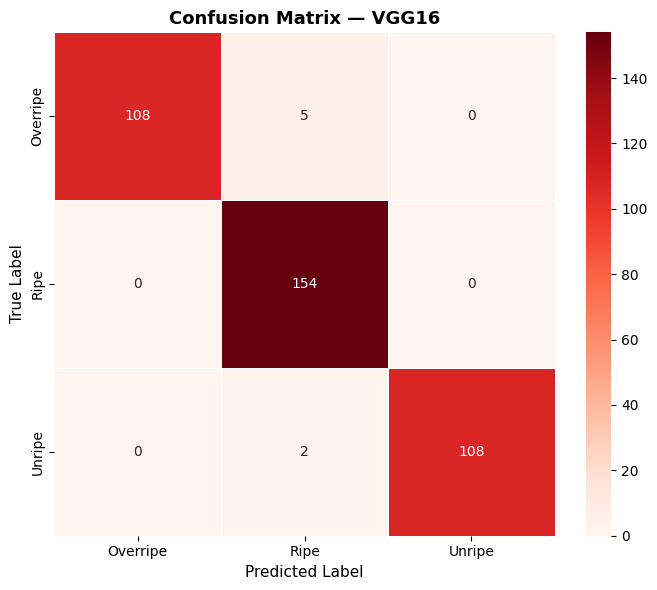

Classification Report — VGG16
              precision    recall  f1-score   support

    Overripe       1.00      0.96      0.98       113
        Ripe       0.96      1.00      0.98       154
      Unripe       1.00      0.98      0.99       110

    accuracy                           0.98       377
   macro avg       0.99      0.98      0.98       377
weighted avg       0.98      0.98      0.98       377



In [21]:
test_generator.reset()
y_pred_vgg = np.argmax(model_vgg.predict(test_generator, verbose=1), axis=1)

cm_vgg = confusion_matrix(y_true, y_pred_vgg)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Reds',
            xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5)
plt.title('Confusion Matrix — VGG16', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()

print("Classification Report — VGG16")
print("=" * 55)
print(classification_report(y_true, y_pred_vgg, target_names=CLASSES))

### 16.3 Akurasi pada Data Test

In [22]:
test_generator.reset()
_, acc_test_resnet = model_resnet.evaluate(test_generator, verbose=0)
test_generator.reset()
_, acc_test_vgg    = model_vgg.evaluate(test_generator, verbose=0)

print("╔══════════════════════════════════════════╗")
print("║       AKURASI DATA TEST                  ║")
print("╠══════════════════════════════════════════╣")
print(f"║  ResNet50 Test Accuracy : {acc_test_resnet:.4f} ({acc_test_resnet*100:.2f}%)  ║")
print(f"║  VGG16    Test Accuracy : {acc_test_vgg:.4f} ({acc_test_vgg*100:.2f}%)  ║")
print("╚══════════════════════════════════════════╝")

╔══════════════════════════════════════════╗
║       AKURASI DATA TEST                  ║
╠══════════════════════════════════════════╣
║  ResNet50 Test Accuracy : 0.4483 (44.83%)  ║
║  VGG16    Test Accuracy : 0.9814 (98.14%)  ║
╚══════════════════════════════════════════╝


## 17. Simpan Model

In [23]:
os.makedirs("models", exist_ok=True)

model_resnet.save("models/model_resnet50_banana.h5")
model_vgg.save("models/model_vgg16_banana.h5")

print("Model tersimpan di folder models/:")
print("  ✓ models/model_resnet50_banana.h5")
print("  ✓ models/model_vgg16_banana.h5")

c:\Users\HYPE AMD\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\model.py:342: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  warnings.warn(


ValueError: Unable to synchronously create dataset (name already exists)

## 18. Prediksi Citra Baru (Inference)

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_banana(img_path, model, model_name="Model"):
    """Prediksi tingkat kematangan pisang dari satu citra."""
    img       = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    probs     = model.predict(img_array, verbose=0)[0]
    pred_idx  = np.argmax(probs)
    pred_kelas = CLASSES[pred_idx]
    confidence = probs[pred_idx] * 100

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(keras_image.load_img(img_path, target_size=IMG_SIZE))
    axes[0].axis('off')
    axes[0].set_title(f"Prediksi: {pred_kelas}\n({confidence:.2f}%)", fontsize=12, fontweight='bold')

    bar_colors = ['#4CAF50' if i == pred_idx else '#90CAF9' for i in range(NUM_CLASSES)]
    axes[1].barh(CLASSES, probs * 100, color=bar_colors)
    axes[1].set_xlabel("Probabilitas (%)")
    axes[1].set_title(f"[{model_name}] Distribusi Probabilitas", fontsize=11)
    axes[1].set_xlim([0, 100])
    for i, v in enumerate(probs * 100):
        axes[1].text(v + 1, i, f"{v:.1f}%", va='center', fontsize=10)

    plt.suptitle(f"Hasil Prediksi — {model_name}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return pred_kelas, confidence

# ── Contoh penggunaan ─────────────────────────────────────────────────
# predict_banana("dataset/test/Ripe/contoh.jpg", model_resnet, "ResNet50")
# predict_banana("dataset/test/Ripe/contoh.jpg", model_vgg,    "VGG16")
print("Fungsi predict_banana() siap.")
print("Contoh: predict_banana('path/gambar.jpg', model_resnet, 'ResNet50')")